# 01 · Data understanding — Home Credit `application_train`

**Purpose.** Milestone 1 of RiskPilot AI was designed before the data could be
downloaded, so the preprocessing choices coded in `riskpilot` rest on documented
conventions of the Home Credit dataset. This notebook checks those assumptions
against the real table, records what the data actually looks like, and states the
consequence of each finding for the baseline. No model is fitted here.

**Scope.** Only `application_train.csv` (one row per loan application). The
relational tables are reserved for the feature-engineering milestone.

**Division of labour.** Every check is a function of `riskpilot.data.validation`;
the notebook only calls them, looks at the output and comments. If a check is
worth keeping, it lives in the package and is unit-tested, not here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from riskpilot import config
from riskpilot.data import validation as v
from riskpilot.data.load import load_application_train
from riskpilot.models.evaluate import (
    GRID_COLOR,
    MODEL_COLOR,
    REFERENCE_COLOR,
    SECOND_COLOR,
    save_metrics,
)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 130)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": GRID_COLOR,
        "axes.grid": True,
        "grid.color": GRID_COLOR,
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "legend.frameon": False,
    }
)
TARGET = config.TARGET_COL
print("dataset:", config.APPLICATION_TRAIN_PATH.relative_to(config.PROJECT_ROOT).as_posix())

dataset: data/raw/application_train.csv


In [2]:
df = load_application_train()
print(f"shape: {df.shape[0]:,} rows x {df.shape[1]} columns | in-memory size: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB")
df.head(3)

shape: 307,511 rows x 122 columns | in-memory size: 530 MB


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 1. Structure and identifier

`SK_ID_CURR` must be a pure row key: unique, and carrying no information about the
target. If the identifier were predictive (for example because rows were appended in
time order and the default rate drifted), dropping it would still be right, but the
random split would need to be reconsidered.

In [3]:
overview = v.dataset_overview(df)
display(pd.Series(overview, name="value"))

id_col = df[config.ID_COL]
print(
    f"{config.ID_COL}: unique={id_col.is_unique}, monotonic={id_col.is_monotonic_increasing}, "
    f"range=[{id_col.min()}, {id_col.max()}]"
)
print(f"univariate ROC-AUC of {config.ID_COL} against {TARGET}: {roc_auc_score(df[TARGET], id_col):.4f} (0.5 = no signal)")
deciles = pd.qcut(id_col, 10, labels=False)
print("default rate by identifier decile:", df.groupby(deciles, observed=True)[TARGET].mean().round(4).tolist())

n_rows                                                  307511
n_columns                                                  122
memory_mb                                           529.515493
n_duplicate_rows                                             0
dtype_counts        {'float64': 65, 'int64': 41, 'object': 16}
id_column                                           SK_ID_CURR
n_duplicate_ids                                              0
id_is_unique                                              True
Name: value, dtype: object

SK_ID_CURR: unique=True, monotonic=True, range=[100002, 456255]
univariate ROC-AUC of SK_ID_CURR against TARGET: 0.4978 (0.5 = no signal)
default rate by identifier decile: [0.0801, 0.0801, 0.0826, 0.0829, 0.0821, 0.0801, 0.0809, 0.0797, 0.0797, 0.0791]


**Finding.** No duplicate rows, no duplicate identifiers, and the identifier is
uninformative (AUC ≈ 0.50, flat default rate across deciles). It is dropped before
modeling (`riskpilot.data.load.split_features_target`) and used only to persist the
split membership.

## 2. Target

`TARGET = 1` means the client had payment difficulties. The prevalence is the single
most important number of the project: it sets the null-model references for every
probabilistic metric and it is the base rate the probabilities must respect.

In [4]:
v.validate_target(df[TARGET])
target = v.summarize_target(df[TARGET])
display(pd.Series(target, name="value"))

p = target["prevalence"]
print(
    "null-model references at this prevalence -> "
    f"Brier = p(1-p) = {p * (1 - p):.4f} | log loss = {-(p * np.log(p) + (1 - p) * np.log(1 - p)):.4f} | "
    f"average precision = {p:.4f} | ROC-AUC = 0.5"
)

n                                     307511
n_missing                                  0
value_counts       {'0': 282686, '1': 24825}
n_positive                             24825
prevalence                          0.080729
imbalance_ratio                     11.38715
Name: value, dtype: object

null-model references at this prevalence -> Brier = p(1-p) = 0.0742 | log loss = 0.2805 | average precision = 0.0807 | ROC-AUC = 0.5


**Finding.** Prevalence 8.07 % (24,825 defaults in 307,511 applications, 1 : 11.4).
Accuracy is meaningless here; the baseline is judged on ranking (ROC-AUC, average
precision) and on probability quality (log loss, Brier, calibration), each next to
the constant "predict the prevalence" model.

## 3. Feature types and cardinality

The pipeline infers the numeric / categorical split from dtypes on the training
partition. Two things are worth checking on the real table: how many "numeric"
columns are actually binary flags or small integer codes (they will be standardized
like any other number), and how large the one-hot encoding becomes.

In [5]:
types = v.split_feature_types(df)
nunique = df[types.numeric].nunique()
print(f"numeric: {len(types.numeric)} | categorical: {len(types.categorical)}")
print(
    "numeric columns by number of distinct values -> "
    f"<=2: {(nunique <= 2).sum()}, 3-10: {((nunique > 2) & (nunique <= 10)).sum()}, "
    f"11-50: {((nunique > 10) & (nunique <= 50)).sum()}, >50: {(nunique > 50).sum()}"
)
print("binary numeric flags:", ", ".join(nunique[nunique <= 2].index))

card = v.categorical_cardinality(df)
display(card)

n_onehot = int((card["n_unique"] + (card["frac_missing"] > 0)).sum())
# +1: the DAYS_EMPLOYED sentinel becomes NaN inside the pipeline and gets its own indicator.
n_indicators = int(df[types.numeric].isna().any().sum()) + 1
n_total = n_onehot + len(types.numeric) + n_indicators
print(f"expected transformed width: {len(types.numeric)} numeric + {n_indicators} missing indicators + {n_onehot} one-hot = {n_total}")
print(f"dense float64 design matrix for an 80 % training split: ~{0.8 * len(df) * n_total * 8 / 1e9:.2f} GB")

numeric: 104 | categorical: 16
numeric columns by number of distinct values -> <=2: 32, 3-10: 7, 11-50: 16, >50: 49
binary numeric flags: FLAG_MOBIL, FLAG_EMP_PHONE, FLAG_WORK_PHONE, FLAG_CONT_MOBILE, FLAG_PHONE, FLAG_EMAIL, REG_REGION_NOT_LIVE_REGION, REG_REGION_NOT_WORK_REGION, LIVE_REGION_NOT_WORK_REGION, REG_CITY_NOT_LIVE_CITY, REG_CITY_NOT_WORK_CITY, LIVE_CITY_NOT_WORK_CITY, FLAG_DOCUMENT_2, FLAG_DOCUMENT_3, FLAG_DOCUMENT_4, FLAG_DOCUMENT_5, FLAG_DOCUMENT_6, FLAG_DOCUMENT_7, FLAG_DOCUMENT_8, FLAG_DOCUMENT_9, FLAG_DOCUMENT_10, FLAG_DOCUMENT_11, FLAG_DOCUMENT_12, FLAG_DOCUMENT_13, FLAG_DOCUMENT_14, FLAG_DOCUMENT_15, FLAG_DOCUMENT_16, FLAG_DOCUMENT_17, FLAG_DOCUMENT_18, FLAG_DOCUMENT_19, FLAG_DOCUMENT_20, FLAG_DOCUMENT_21


,column,n_unique,frac_missing
0,ORGANIZATION_TYPE,58,0.000000
1,OCCUPATION_TYPE,18,0.313455
2,NAME_INCOME_TYPE,8,0.000000
3,NAME_TYPE_SUITE,7,0.004201
4,WEEKDAY_APPR_PROCESS_START,7,0.000000
5,WALLSMATERIAL_MODE,7,0.508408
6,NAME_FAMILY_STATUS,6,0.000000
7,NAME_HOUSING_TYPE,6,0.000000
8,NAME_EDUCATION_TYPE,5,0.000000
9,FONDKAPREMONT_MODE,4,0.683862


expected transformed width: 104 numeric + 62 missing indicators + 146 one-hot = 312
dense float64 design matrix for an 80 % training split: ~0.61 GB


**Finding.** 104 numeric and 16 categorical columns. 32 of the numeric columns are
0/1 flags and 7 more are small codes; they are standardized with the rest, which is
harmless for a linear model but is revisited in section 7. The largest categorical
column, `ORGANIZATION_TYPE`, has 58 levels; the whole one-hot block is about 146
columns, so the encoding is memory-safe (≈ 0.6 GB dense for the training split).
The one-hot block is emitted sparse, but the `ColumnTransformer` densifies the
result because the numeric block dominates; notebook 02 confirms the actual size.

## 4. Missingness

Missing values are handled inside the pipeline (median + indicator for numbers,
an explicit `"missing"` level for categories). What matters here is whether the
missingness is structural (an informative "not applicable") or noise, because the
indicator columns are features in their own right.

n_columns_with_missing          67.000000
n_columns_over_50pct_missing    41.000000
n_columns_over_20pct_missing    50.000000
total_missing_fraction           0.243959
Name: value, dtype: float64

columns per missingness band: {'none': 55, '0-20%': 17, '20-50%': 9, '>50%': 41}
building block (*_AVG / *_MODE / *_MEDI): 47 columns, 47%-70% missing, only 19 distinct missing counts -> the triples share one pattern

OWN_CAR_AGE missing vs FLAG_OWN_CAR (structural: no car, no car age):


OWN_CAR_AGE missing,False,True
FLAG_OWN_CAR,,
N,0,202924
Y,104582,5


EXT_SOURCE_1 / _2 / _3 missing: ['56.4%', '0.2%', '19.8%']


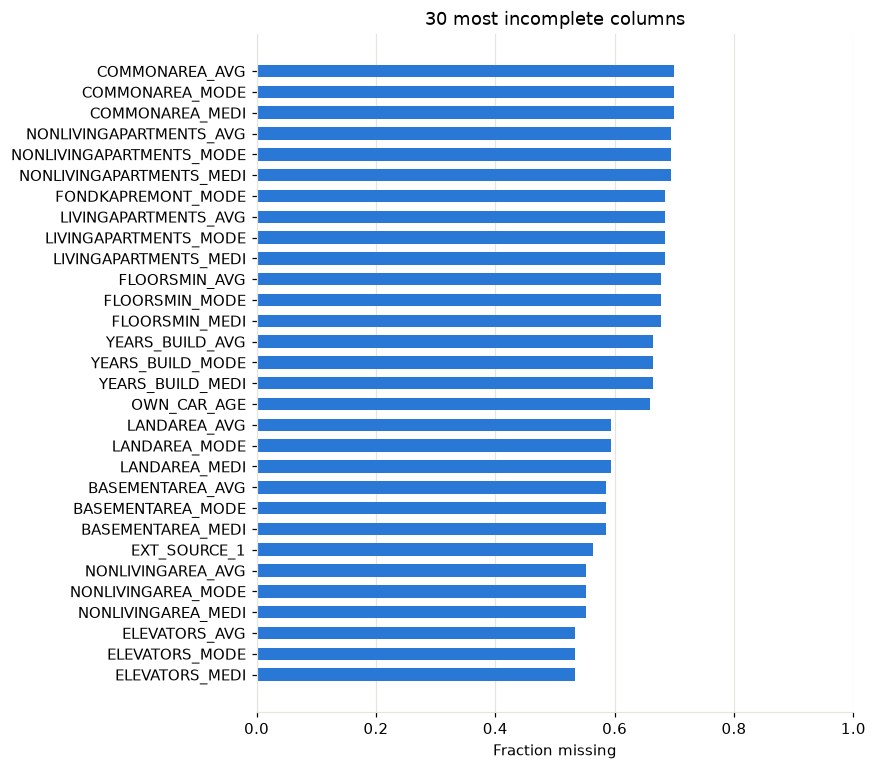

In [6]:
mt = v.missingness_table(df)
summary = v.missingness_summary(df)
display(pd.Series({k: val for k, val in summary.items() if k != "top_missing"}, name="value"))

bands = pd.cut(mt["frac_missing"], [-1e-9, 0, 0.2, 0.5, 1.0], labels=["none", "0-20%", "20-50%", ">50%"])
print("columns per missingness band:", bands.value_counts().reindex(["none", "0-20%", "20-50%", ">50%"]).to_dict())

housing = mt[mt["column"].str.contains(r"_(?:AVG|MODE|MEDI)$", regex=True)]
print(
    f"building block (*_AVG / *_MODE / *_MEDI): {len(housing)} columns, {housing.frac_missing.min():.0%}-{housing.frac_missing.max():.0%} missing, "
    f"only {housing.n_missing.nunique()} distinct missing counts -> the triples share one pattern"
)
print("\nOWN_CAR_AGE missing vs FLAG_OWN_CAR (structural: no car, no car age):")
display(pd.crosstab(df["FLAG_OWN_CAR"], df["OWN_CAR_AGE"].isna(), colnames=["OWN_CAR_AGE missing"]))
print("EXT_SOURCE_1 / _2 / _3 missing:", [f"{df[c].isna().mean():.1%}" for c in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]])

top = mt[mt.n_missing > 0].head(30).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 8))
ax.barh(top["column"], top["frac_missing"], color=MODEL_COLOR, height=0.6)
ax.set_xlim(0, 1)
ax.set_xlabel("Fraction missing")
ax.set_title("30 most incomplete columns")
ax.grid(axis="y", visible=False)
plt.show()

**Finding.** 67 of 122 columns have gaps; 41 are more than half empty and almost
all of those belong to the building-description block, whose `_AVG` / `_MODE` /
`_MEDI` triples are missing together (a household either has the housing record or
not). `OWN_CAR_AGE` is missing exactly when the applicant has no car, and
`EXT_SOURCE_1` is absent for 56 % of applicants. This is structural missingness:
the indicator columns carry information, and median imputation only needs to be
harmless, not accurate. Nothing is dropped for the baseline; the redundancy of the
triples is left to the regularizer (notebook 02 counts the identical columns).

## 5. `DAYS_*` columns and the `DAYS_EMPLOYED` sentinel

All `DAYS_*` columns count days *before* the application, so they must be ≤ 0.
`riskpilot.config.SENTINEL_VALUES` assumes that `DAYS_EMPLOYED == 365243`
(≈ +1000 years) encodes "no employment record". That assumption was never verified
on real data; here it is.

,count,mean,std,min,1%,50%,99%,max
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.0,-24419.0,-15750.0,-8263.0,-7489.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-10894.9,-1213.0,365243.0,365243.0
DAYS_REGISTRATION,307511.0,-4986.120328,3522.886321,-24672.0,-13879.0,-4504.0,-50.0,0.0
DAYS_ID_PUBLISH,307511.0,-2994.202373,1509.450419,-7197.0,-5447.0,-3254.0,-61.0,0.0
DAYS_LAST_PHONE_CHANGE,307510.0,-962.858788,826.808487,-4292.0,-3149.0,-757.0,0.0,0.0


,sentinel,n,frac
DAYS_EMPLOYED,365243.0,55374.0,0.180072


positive values per DAYS_* column: {'DAYS_BIRTH': 0, 'DAYS_EMPLOYED': 55374, 'DAYS_REGISTRATION': 0, 'DAYS_ID_PUBLISH': 0, 'DAYS_LAST_PHONE_CHANGE': 0}
positive DAYS_EMPLOYED values other than the sentinel: 0

share of sentinel rows by NAME_INCOME_TYPE:


sentinel,False,True
NAME_INCOME_TYPE,,
Businessman,1.0000,0.0000
Commercial associate,1.0000,0.0000
Maternity leave,1.0000,0.0000
Pensioner,0.0002,0.9998
State servant,1.0000,0.0000
Student,1.0000,0.0000
Unemployed,0.0000,1.0000
Working,1.0000,0.0000


sentinel rows coincide exactly with ORGANIZATION_TYPE == 'XNA': True
default rate: {False: 0.0866, True: 0.054}


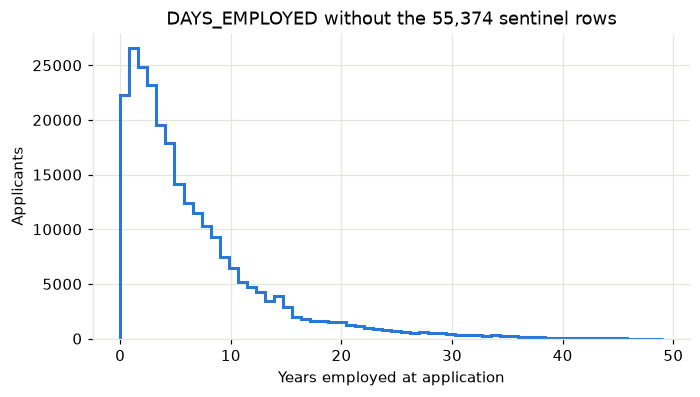

DAYS_LAST_PHONE_CHANGE == 0 on 12.3% of rows; it is a legal value (changed on the day) and is left untouched


In [7]:
days = [c for c in df.columns if c.startswith("DAYS_")]
display(df[days].describe(percentiles=[0.01, 0.5, 0.99]).T)

sus = v.suspicious_values_report(df)
display(pd.DataFrame(sus["sentinels"]).T)

sentinel = df["DAYS_EMPLOYED"] == config.SENTINEL_VALUES["DAYS_EMPLOYED"]
print("positive values per DAYS_* column:", {c: int((df[c] > 0).sum()) for c in days})
print("positive DAYS_EMPLOYED values other than the sentinel:", int(((df["DAYS_EMPLOYED"] > 0) & ~sentinel).sum()))
print("\nshare of sentinel rows by NAME_INCOME_TYPE:")
display(pd.crosstab(df["NAME_INCOME_TYPE"], sentinel.rename("sentinel"), normalize="index").round(4))
print("sentinel rows coincide exactly with ORGANIZATION_TYPE == 'XNA':", bool((sentinel == (df["ORGANIZATION_TYPE"] == "XNA")).all()))
print("default rate:", df.groupby(sentinel.rename("sentinel"))[TARGET].mean().round(4).to_dict())

years = -df.loc[~sentinel, "DAYS_EMPLOYED"] / 365.25
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(years, bins=60, color=MODEL_COLOR, histtype="step", linewidth=2)
ax.set_xlabel("Years employed at application")
ax.set_ylabel("Applicants")
ax.set_title(f"DAYS_EMPLOYED without the {int(sentinel.sum()):,} sentinel rows")
plt.show()

print(f"DAYS_LAST_PHONE_CHANGE == 0 on {(df['DAYS_LAST_PHONE_CHANGE'] == 0).mean():.1%} of rows; it is a legal value (changed on the day) and is left untouched")

**Finding.** The sentinel is real and is the *only* positive value in any `DAYS_*`
column: 55,374 rows (18.0 %), exactly the pensioners and the unemployed, and exactly
the rows with `ORGANIZATION_TYPE == "XNA"`. Their default rate is lower (5.4 % vs
8.7 %). This is a documented dataset convention, not corruption: the pipeline maps
the value to missing and adds a `DAYS_EMPLOYED` missing indicator, so the linear
model never sees +1000 years and the "no employment record" information survives
(three times over, via the indicator, `NAME_INCOME_TYPE` and `ORGANIZATION_TYPE`).
The remaining employment tenures are plausible (0–49 years); `DAYS_BIRTH` spans
20.5–69.1 years.

## 6. Unknown tokens (`XNA`, `Unknown`)

String columns can encode "unknown" as a token instead of a blank. The question is
whether each token is a meaningful level or a data-quality defect.

In [8]:
display(
    pd.DataFrame(
        [(col, tok, n) for col, found in sus["unknown_tokens"].items() for tok, n in found.items()],
        columns=["column", "token", "rows"],
    )
)
print("CODE_GENDER:", df["CODE_GENDER"].value_counts().to_dict())
print("NAME_FAMILY_STATUS:", df["NAME_FAMILY_STATUS"].value_counts().to_dict())
xna_org = df.loc[df["ORGANIZATION_TYPE"] == "XNA", "NAME_INCOME_TYPE"]
print(f"ORGANIZATION_TYPE == 'XNA' rows that are pensioners or unemployed: {xna_org.isin(['Pensioner', 'Unemployed']).mean():.1%}")

,column,token,rows
0,CODE_GENDER,XNA,4
1,NAME_FAMILY_STATUS,Unknown,2
2,ORGANIZATION_TYPE,XNA,55374


CODE_GENDER: {'F': 202448, 'M': 105059, 'XNA': 4}
NAME_FAMILY_STATUS: {'Married': 196432, 'Single / not married': 45444, 'Civil marriage': 29775, 'Separated': 19770, 'Widow': 16088, 'Unknown': 2}
ORGANIZATION_TYPE == 'XNA' rows that are pensioners or unemployed: 100.0%


**Finding.** `ORGANIZATION_TYPE == "XNA"` (55,374 rows) is the legitimate "no
employer" level of the sentinel population and stays as a one-hot column.
`CODE_GENDER == "XNA"` (4 rows) and `NAME_FAMILY_STATUS == "Unknown"` (2 rows) are
genuine defects but negligible: they become rare one-hot levels whose coefficients
are shrunk by the L2 penalty, and `handle_unknown="ignore"` covers the case where
they only appear in the test partition. No rows are removed.

## 7. Extreme values and what standardization does with them

The numeric branch is median imputation followed by `StandardScaler`. Standardization
divides by the standard deviation, which a single extreme value can inflate; and a
near-constant 0/1 flag gives its rare rows an enormous z-score. Both effects are
quantified here and their consequence for the fitted model is checked in notebook 02.

In [9]:
display(pd.DataFrame(sus["extreme_numeric"]).T)

cols = [
    "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE", "CNT_CHILDREN",
    "OBS_30_CNT_SOCIAL_CIRCLE", "DEF_30_CNT_SOCIAL_CIRCLE", "AMT_REQ_CREDIT_BUREAU_QRT", "OWN_CAR_AGE",
]
q = df[cols].quantile([0.5, 0.99, 0.999]).T
q.columns = ["median", "q99", "q99.9"]
q["max"] = df[cols].max()
display(q)

income = df["AMT_INCOME_TOTAL"]
display(df.nlargest(3, "AMT_INCOME_TOTAL")[["SK_ID_CURR", "AMT_INCOME_TOTAL", "AMT_CREDIT", "NAME_INCOME_TYPE", "OCCUPATION_TYPE", TARGET]])
print(
    f"AMT_INCOME_TOTAL std with the 117M row: {income.std():,.0f} | without it: {income[income < 1e8].std():,.0f} | "
    f"z-score of that row after StandardScaler: {(income.max() - income.mean()) / income.std(ddof=0):.0f}"
)

const = v.constant_features(df)
display(const)
share = 1 - const.set_index("column").loc["FLAG_MOBIL", "top_frac"]
print(f"FLAG_MOBIL: {int(round(share * len(df)))} row(s) differ from the rest; after standardization that row sits at |z| = {np.sqrt((1 - share) / share):.0f}")
print("negative AMT_* / CNT_* values:", sus["negative_amounts"] or "none")

,max,q99,median,ratio_max_to_q99
AMT_INCOME_TOTAL,117000000.0,472500.0,147150.0,247.619048
AMT_REQ_CREDIT_BUREAU_QRT,261.0,2.0,0.0,130.500000


,median,q99,q99.9,max
AMT_INCOME_TOTAL,147150.0,472500.0,900000.0,117000000.0
AMT_CREDIT,513531.0,1854000.0,2517300.0,4050000.0
AMT_ANNUITY,24903.0,70006.5,110047.5,258025.5
AMT_GOODS_PRICE,450000.0,1800000.0,2250000.0,4050000.0
CNT_CHILDREN,0.0,3.0,4.0,19.0
OBS_30_CNT_SOCIAL_CIRCLE,0.0,10.0,17.0,348.0
DEF_30_CNT_SOCIAL_CIRCLE,0.0,2.0,4.0,34.0
AMT_REQ_CREDIT_BUREAU_QRT,0.0,2.0,4.0,261.0
OWN_CAR_AGE,9.0,64.0,65.0,91.0


,SK_ID_CURR,AMT_INCOME_TOTAL,AMT_CREDIT,NAME_INCOME_TYPE,OCCUPATION_TYPE,TARGET
12840,114967,117000000.0,562491.0,Working,Laborers,1
203693,336147,18000090.0,675000.0,Commercial associate,NaN,0
246858,385674,13500000.0,1400503.5,Commercial associate,NaN,0


AMT_INCOME_TOTAL std with the 117M row: 237,123 | without it: 108,812 | z-score of that row after StandardScaler: 493


,column,n_unique,top_value,top_frac,is_constant
0,FLAG_MOBIL,2,1,0.999997,False
1,FLAG_DOCUMENT_12,2,0,0.999993,False
2,FLAG_DOCUMENT_10,2,0,0.999977,False
3,FLAG_DOCUMENT_2,2,0,0.999958,False
4,FLAG_DOCUMENT_4,2,0,0.999919,False
5,FLAG_DOCUMENT_7,2,0,0.999808,False
6,FLAG_DOCUMENT_17,2,0,0.999733,False
7,FLAG_DOCUMENT_21,2,0,0.999665,False
8,FLAG_DOCUMENT_20,2,0,0.999493,False
9,FLAG_DOCUMENT_19,2,0,0.999405,False


FLAG_MOBIL: 1 row(s) differ from the rest; after standardization that row sits at |z| = 555
negative AMT_* / CNT_* values: none


**Finding.** One applicant reports an income of 117,000,000 (247 × the 99th
percentile, 780 × the median), most likely a data-entry error that cannot be
verified. It alone inflates the standard deviation of `AMT_INCOME_TOTAL` by 2.4 ×,
which compresses every other applicant's standardized income into a narrow band.
Eighteen `FLAG_DOCUMENT_*` / `FLAG_MOBIL` style columns are constant for ≥ 99 % of
rows; the deviating rows receive z-scores in the hundreds. No amounts or counts are
negative.

**Decision.** Nothing is clipped, transformed or dropped for the baseline: these are
not verifiable errors, the baseline is meant to be plain, and notebook 02 shows the
fitted coefficients on those columns are tiny, so the effect is a lost signal
(income is effectively unused) rather than a distorted one. Robust scaling or
log-transforms of the amount columns and leaving 0/1 flags unscaled are recorded as
candidate revisions for the challenger-model milestone, where they can be compared
on the same split.

## 8. Leakage screen and the split question

Two heuristics from `riskpilot.data.validation.leakage_screen`: column names that
suggest post-outcome information, and numeric features whose *univariate* AUC is
implausibly high for something known at application time.

In [10]:
leak = v.leakage_screen(df)
print("name-based flags:", leak["name_based_flags"] or "none")
print(f"features with univariate AUC >= {leak['auc_threshold']}:", leak["high_separation_features"] or "none")
display(pd.Series(leak["top_univariate_auc"], name="max(AUC, 1 - AUC)").round(4).to_frame())
print("time-related columns:", [c for c in df.columns if "APPR_PROCESS_START" in c], "-> weekday and hour only; no application date")

name-based flags: none
features with univariate AUC >= 0.8: none


,"max(AUC, 1 - AUC)"
EXT_SOURCE_3,0.6794
EXT_SOURCE_1,0.6657
EXT_SOURCE_2,0.6561
DAYS_BIRTH,0.5830
OWN_CAR_AGE,0.5589
DAYS_LAST_PHONE_CHANGE,0.5569
DAYS_ID_PUBLISH,0.5557
FLOORSMAX_AVG,0.5504
FLOORSMAX_MEDI,0.5500
REGION_RATING_CLIENT_W_CITY,0.5492


time-related columns: ['WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START'] -> weekday and hour only; no application date


**Finding.** No column name suggests post-outcome information and no feature comes
close to the 0.80 alarm level. The strongest single predictors are the three external
scores `EXT_SOURCE_3/1/2` (AUC 0.66–0.68), which are bureau-style scores available at
application time: legitimate, and expected to dominate the linear model. Everything
else is below 0.59 on its own.

**Split.** The table carries no application date (only the weekday and hour of the
appointment), so a chronological holdout cannot be built from it. The baseline uses
a stratified random 80/20 holdout with a fixed seed; the stratification keeps the
8.07 % prevalence identical in both partitions. The caveat is honest: a random split
measures interpolation within the same period, not performance on future applicants.

## 9. Univariate signal (for intuition, not for feature selection)

A short look at the strongest raw signals so that the coefficients in notebook 02
can be read against something. No feature is selected or discarded on this basis.

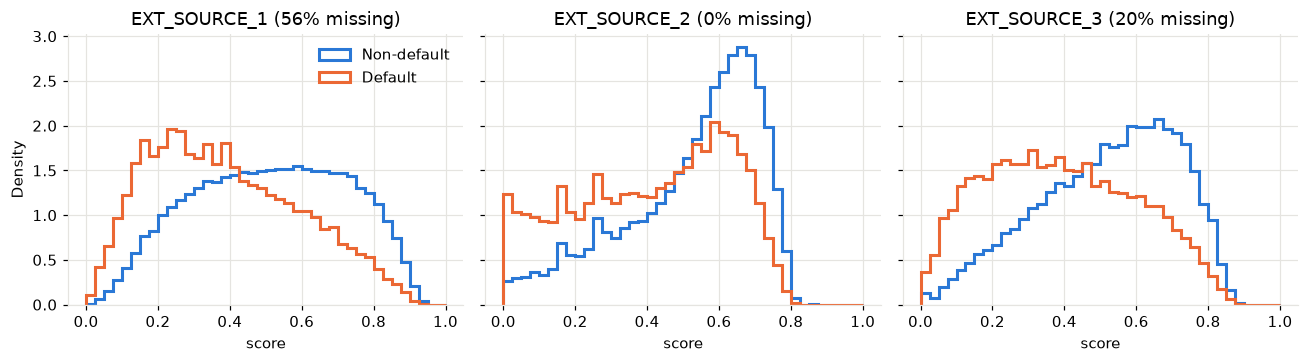

,n,default_rate
DAYS_BIRTH,,
"[20, 25)",12233,0.1229
"[25, 30)",32953,0.1113
"[30, 35)",39476,0.1027
"[35, 40)",42855,0.0897
"[40, 45)",41406,0.0783
"[45, 50)",35193,0.0742
"[50, 55)",34997,0.0667
"[55, 60)",33097,0.0554
"[60, 70)",35301,0.0492


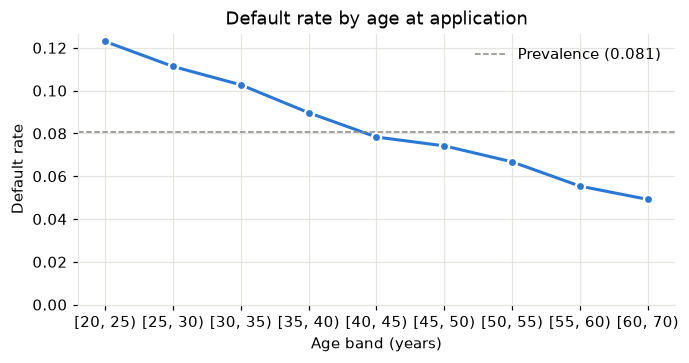

,n,default_rate
NAME_INCOME_TYPE,,
Maternity leave,5,0.4000
Unemployed,22,0.3636
Working,158774,0.0959
Commercial associate,71617,0.0748
State servant,21703,0.0575
Pensioner,55362,0.0539
Businessman,10,0.0000
Student,18,0.0000


,n,default_rate
NAME_EDUCATION_TYPE,,
Lower secondary,3816,0.1093
Secondary / secondary special,218391,0.0894
Incomplete higher,10277,0.0848
Higher education,74863,0.0536
Academic degree,164,0.0183


,n,default_rate
CODE_GENDER,,
M,105059,0.1014
F,202448,0.0700
XNA,4,0.0000


,n,default_rate
NAME_CONTRACT_TYPE,,
Cash loans,278232,0.0835
Revolving loans,29279,0.0548


corr(AMT_CREDIT, AMT_GOODS_PRICE) = 0.987 -> near-collinear pair; the model will use their difference


In [11]:
y = df[TARGET]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
bins = np.linspace(0, 1, 41)
for ax, col in zip(axes, ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]):
    s = df[col]
    ax.hist(s[y == 0].dropna(), bins=bins, density=True, histtype="step", linewidth=2, color=MODEL_COLOR, label="Non-default")
    ax.hist(s[y == 1].dropna(), bins=bins, density=True, histtype="step", linewidth=2, color=SECOND_COLOR, label="Default")
    ax.set_title(f"{col} ({s.isna().mean():.0%} missing)")
    ax.set_xlabel("score")
axes[0].set_ylabel("Density")
axes[0].legend()
plt.tight_layout()
plt.show()

age = -df["DAYS_BIRTH"] / 365.25
age_bands = pd.cut(age, [20, 25, 30, 35, 40, 45, 50, 55, 60, 70], right=False)
by_age = df.groupby(age_bands, observed=True)[TARGET].agg(n="size", default_rate="mean")
display(by_age.round(4))
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot([str(i) for i in by_age.index], by_age["default_rate"], color=MODEL_COLOR, marker="o", linewidth=2, markersize=6, markeredgecolor="white", markeredgewidth=1.5)
ax.axhline(y.mean(), color=REFERENCE_COLOR, linestyle="--", linewidth=1, label=f"Prevalence ({y.mean():.3f})")
ax.set_ylim(0, None)
ax.set_xlabel("Age band (years)")
ax.set_ylabel("Default rate")
ax.set_title("Default rate by age at application")
ax.legend()
plt.show()

for col in ["NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "CODE_GENDER", "NAME_CONTRACT_TYPE"]:
    display(df.groupby(col)[TARGET].agg(n="size", default_rate="mean").sort_values("default_rate", ascending=False).round(4))
print("corr(AMT_CREDIT, AMT_GOODS_PRICE) =", round(df[["AMT_CREDIT", "AMT_GOODS_PRICE"]].corr().iloc[0, 1], 3), "-> near-collinear pair; the model will use their difference")

## 10. Persist the validation report

The full JSON report from `riskpilot.data.validation.run_validation` is saved next to
the metrics so that the technical report and the README can cite it.

In [12]:
report = v.run_validation(df)
out = save_metrics(report, config.METRICS_DIR / "data_validation.json")
print("saved", out.relative_to(config.PROJECT_ROOT).as_posix(), f"({out.stat().st_size / 1e3:.0f} kB)")

saved artifacts/metrics/data_validation.json (8 kB)


## Summary: findings and what the baseline does with them

| Finding (real data) | Decision for the baseline | Where |
|---|---|---|
| 307,511 × 122, no duplicate rows or ids, id uninformative | drop `SK_ID_CURR`, keep it only for split membership | `data.load.split_features_target` |
| prevalence 8.07 % | no class weights, no threshold; null-model references in every metric | `models.evaluate.compute_metrics` |
| 67 columns with gaps, 41 over 50 %, mostly the structural building block | median + missing indicator (numeric), `"missing"` level (categorical); nothing dropped | `features.preprocessing.build_preprocessor` |
| `DAYS_EMPLOYED == 365243` on 18 % of rows = pensioners / unemployed | sentinel → NaN + indicator, verified as the only positive `DAYS_*` value | `config.SENTINEL_VALUES`, `features.preprocessing.clean_features` |
| `XNA` in `ORGANIZATION_TYPE` (55k) is a real level; 6 defective rows elsewhere | keep as one-hot levels | `OneHotEncoder(handle_unknown="ignore")` |
| max cardinality 58 (`ORGANIZATION_TYPE`), ≈ 146 one-hot columns | plain one-hot, memory-safe | same |
| 117M income outlier, near-constant flags stretch `StandardScaler` | unchanged for the baseline; quantified; candidate revision for the next milestone | notebook 02 §7 |
| no leakage candidates; `EXT_SOURCE_*` strongest at AUC ≤ 0.68 | all 120 raw features kept | `data.validation.leakage_screen` |
| no application date | stratified random 80/20 holdout, seed 42, membership persisted | `models.train.make_split` |